# TorchRL A2C

In this tutorial, we will learn how to use A2C

This notebook was modified from the official tutorials provided by torchRL: 

**Get started with TorchRL's modules**
Author: `Vincent Moens <https://github.com/vmoens>`
url: https://docs.pytorch.org/rl/stable/tutorials/getting-started-3.html

### Install TorchRL

First let's install torchrl and tensordict.


In [2]:
#!pip install tensordict
#!pip install torchrl

In [3]:
import torchvision 

from tensordict.nn import TensorDictSequential

import torch
from tensordict.nn import TensorDictModule
from tensordict import TensorDict
from torchrl.envs import GymEnv
from torch import nn

from torchrl.modules import QValueActor
from torch.optim import Adam, RMSprop
from torchrl.modules import QValueActor

### REINFORCE with Baseline

We saw in the last tutorial how we can use policy based algorithms to choose actions that lead to good outcomes. However, the resulting algorihtm took a long time to learn useful actions, and showed quite a lot of variance in performance.

Let's start to combine what we've learned with policy based-algorihtms with what we already know about value-based algorithms. This will lead us down a path to many state-of-the-art algorithms today.





In [4]:
from torchrl.envs import TransformedEnv, Compose, ObservationNorm, DoubleToFloat, StepCounter


base_env = GymEnv("Pendulum-v1")

base_env

env = TransformedEnv(
    base_env,
    Compose(
        # normalize observations
        ObservationNorm(in_keys=["observation"]),
        DoubleToFloat(),
        StepCounter(),
    ),
)
env.transform[0].init_stats(num_iter=1000, reduce_dim=0, cat_dim=0)

from torchrl.envs import check_env_specs

check_env_specs(env)

2026-03-10 10:54:40,917 [torchrl][INFO]    check_env_specs succeeded! [END]


### Policy

In [5]:
from torchrl.modules import ProbabilisticActor, TanhNormal
from torchrl.modules import NormalParamExtractor

num_cells = 32
device = "cpu"

actor_net = nn.Sequential(
    nn.LazyLinear(num_cells, device=device),
    nn.Tanh(),
    nn.LazyLinear(num_cells, device=device),
    nn.Tanh(),
    nn.LazyLinear(num_cells, device=device),
    nn.Tanh(),
    nn.LazyLinear(2 * env.action_spec.shape[-1], device=device),
    NormalParamExtractor(),
)

policy_module = TensorDictModule(
    actor_net, in_keys=["observation"], out_keys=["loc", "scale"]
)

policy_module = ProbabilisticActor(
    module=policy_module,
    spec=env.action_spec,
    in_keys=["loc", "scale"],
    distribution_class=TanhNormal,
    distribution_kwargs={
        "low": env.action_spec_unbatched.space.low,
        "high": env.action_spec_unbatched.space.high,
    },
    return_log_prob=True,
)

### Value function

In [6]:

n_obs = env.observation_spec["observation"].shape[-1]
nodes = 16

#create a model: takes observations as inputs, and outputs categorical actions
model = nn.Sequential(
    nn.Linear(n_obs,nodes),
    nn.ReLU(),
    nn.Linear(nodes,nodes),
    nn.ReLU(),
    nn.Linear(nodes, 1),
)

#go from observations to logits using the model
value_net = TensorDictModule(
    model,
    in_keys=["observation"],
    out_keys=["state_value"],          
)





### Training loop

Create the environment
the actor and the critic
and the collector

In [7]:

from torchrl.envs import TransformedEnv, Compose, ObservationNorm, DoubleToFloat, StepCounter, RewardScaling
from torchrl.objectives import A2CLoss
from torchrl.objectives.value import TD0Estimator

base_env = GymEnv("Pendulum-v1")

base_env

RewardScaling(loc=0, scale=0.1)  # simple fixed scaling


env = TransformedEnv(
    base_env,
    Compose(
        # normalize observations
        ObservationNorm(in_keys=["observation"]),
        DoubleToFloat(),
        StepCounter(),
        RewardScaling(loc=0, scale=0.1),
    ),
)
env.transform[0].init_stats(num_iter=1000, reduce_dim=0, cat_dim=0)

from torchrl.envs import check_env_specs

check_env_specs(env)

from torchrl.modules import ProbabilisticActor, TanhNormal
from torchrl.modules import NormalParamExtractor

num_cells = 32
device = "cpu"

actor_net = nn.Sequential(
    nn.LazyLinear(num_cells, device=device),
    nn.Tanh(),
    nn.LazyLinear(num_cells, device=device),
    nn.Tanh(),
    nn.LazyLinear(num_cells, device=device),
    nn.Tanh(),
    nn.LazyLinear(2 * env.action_spec.shape[-1], device=device),
    NormalParamExtractor(),
)

policy_module = TensorDictModule(
    actor_net, in_keys=["observation"], out_keys=["loc", "scale"]
)

policy_module = ProbabilisticActor(
    module=policy_module,
    spec=env.action_spec,
    in_keys=["loc", "scale"],
    distribution_class=TanhNormal,
    distribution_kwargs={
        "low": env.action_spec_unbatched.space.low,
        "high": env.action_spec_unbatched.space.high,
    },
    return_log_prob=True,
)

#n_obs = env.observation_spec["observation"].shape[-1]

#create a model: takes observations as inputs, and outputs categorical actions
model = nn.Sequential(
    nn.LazyLinear(num_cells),
    nn.Tanh(),
    nn.LazyLinear(num_cells),
    nn.Tanh(),
    nn.LazyLinear(1),
)

#go from observations to logits using the model
value_net = TensorDictModule(
    model,
    in_keys=["observation"],
    out_keys=["state_value"],          
)

# Initialize lazy layers with a dummy forward pass
dummy_td = env.reset()
policy_module(dummy_td)   # initializes actor lazy layers
value_net(dummy_td)       # initializes critic lazy layers



from torchrl.collectors import SyncDataCollector
from torchrl.data import LazyTensorStorage, ReplayBuffer, SamplerWithoutReplacement
from torchrl.record import CSVLogger
import torch.nn.functional as F

logger = CSVLogger(exp_name="my_exp")

frames_per_batch = 200
total_frames = 1_000_000
gamma = 0.99


collector = SyncDataCollector(
    env,
    policy_module,
    frames_per_batch=frames_per_batch,
    total_frames=total_frames,
    split_trajs=False,
    device=device,
)


2026-03-10 10:54:42,176 [torchrl][INFO]    check_env_specs succeeded! [END]


/home/titan2/data/conda-envs/torchrl_latest/lib/python3.12/site-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(


Create the loss function and the optimization code

In [8]:
from torchrl.objectives.value import GAE

loss_fn = A2CLoss(
    actor_network=policy_module,
    critic_network=value_net,
    entropy_bonus=True,
    entropy_coeff=0.001,  
    critic_coeff=0.5,      
    loss_critic_type="l2",
)

# GAE needs to be computed before the loss - set it up as a separate module
adv_module = GAE(
    gamma=0.99,
    lmbda=0.95,
    value_network=value_net,
    average_gae=True,
)

optim = RMSprop(loss_fn.parameters(), lr=0.0007, eps=1e-5)



Run a loop to gather agent-environment experience and allow learning

In [13]:
#########

from torchrl.envs import TransformedEnv, Compose, ObservationNorm, DoubleToFloat, StepCounter, RewardScaling
from torchrl.objectives import A2CLoss
from torchrl.objectives.value import TD0Estimator

base_env = GymEnv("Pendulum-v1")

base_env


env = TransformedEnv(
    base_env,
    Compose(
        # normalize observations
        ObservationNorm(in_keys=["observation"]),
        DoubleToFloat(),
        StepCounter(),
        RewardScaling(loc=0, scale=0.01),
    ),
)
env.transform[0].init_stats(num_iter=1000, reduce_dim=0, cat_dim=0)

from torchrl.envs import check_env_specs

check_env_specs(env)

from torchrl.modules import ProbabilisticActor, TanhNormal
from torchrl.modules import NormalParamExtractor

num_cells = 32
device = "cpu"

actor_net = nn.Sequential(
    nn.LazyLinear(num_cells, device=device),
    nn.Tanh(),
    nn.LazyLinear(num_cells, device=device),
    nn.Tanh(),
    nn.LazyLinear(num_cells, device=device),
    nn.Tanh(),
    nn.LazyLinear(2 * env.action_spec.shape[-1], device=device),
    NormalParamExtractor(),
)

policy_module = TensorDictModule(
    actor_net, in_keys=["observation"], out_keys=["loc", "scale"]
)

policy_module = ProbabilisticActor(
    module=policy_module,
    spec=env.action_spec,
    in_keys=["loc", "scale"],
    distribution_class=TanhNormal,
    distribution_kwargs={
        "low": env.action_spec_unbatched.space.low,
        "high": env.action_spec_unbatched.space.high,
    },
    return_log_prob=True,
)

#n_obs = env.observation_spec["observation"].shape[-1]

#create a model: takes observations as inputs, and outputs categorical actions
model = nn.Sequential(
    nn.LazyLinear(num_cells),
    nn.Tanh(),
    nn.LazyLinear(num_cells),
    nn.Tanh(),
    nn.LazyLinear(1),
)

#go from observations to logits using the model
value_net = TensorDictModule(
    model,
    in_keys=["observation"],
    out_keys=["state_value"],          
)

# Initialize lazy layers with a dummy forward pass
dummy_td = env.reset()
policy_module(dummy_td)   # initializes actor lazy layers
value_net(dummy_td)       # initializes critic lazy layers



from torchrl.collectors import SyncDataCollector
from torchrl.data import LazyTensorStorage, ReplayBuffer, SamplerWithoutReplacement
from torchrl.record import CSVLogger
import torch.nn.functional as F

logger = CSVLogger(exp_name="my_exp")

frames_per_batch = 200
total_frames = 1_000_000
gamma = 0.99


collector = SyncDataCollector(
    env,
    policy_module,
    frames_per_batch=frames_per_batch,
    total_frames=total_frames,
    split_trajs=False,
    device=device,
)


######

from torchrl.objectives.value import GAE

loss_fn = A2CLoss(
    actor_network=policy_module,
    critic_network=value_net,
    entropy_bonus=True,
    entropy_coeff=0.001,  
    critic_coeff=0.5,      
    loss_critic_type="l2",
)

# GAE needs to be computed before the loss - set it up as a separate module
adv_module = GAE(
    gamma=0.99,
    lmbda=0.95,
    value_network=value_net,
    average_gae=True,
)

optim = RMSprop(loss_fn.parameters(), lr=0.0003, eps=1e-5)


#####
for data in collector:
    reward = data["next", "reward"].squeeze(-1)

    # GAE must be computed first to populate "advantage" and "value_target" in data
    with torch.no_grad():
        adv_module(data)

    loss_td = loss_fn(data)
    loss = loss_td["loss_objective"] + loss_td["loss_critic"] + loss_td["loss_entropy"]

    optim.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(loss_fn.parameters(), max_norm=0.5)
    optim.step()

    print(
        f"Batch {collector._frames // frames_per_batch:4d} | "
        f"Reward: {reward.mean().item():+7.3f} | "
        f"Actor Loss: {loss_td['loss_objective'].item():+7.3f} | "
        f"Critic Loss: {loss_td['loss_critic'].item():7.3f} | "
        f"Entropy: {loss_td['loss_entropy'].item():7.3f}"
    )

2026-03-10 15:17:02,738 [torchrl][INFO]    check_env_specs succeeded! [END]


/home/titan2/data/conda-envs/torchrl_latest/lib/python3.12/site-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(


Batch    1 | Reward:  -0.062 | Actor Loss:  +0.005 | Critic Loss:   0.525 | Entropy:  -0.001
Batch    2 | Reward:  -0.046 | Actor Loss:  +0.022 | Critic Loss:   0.309 | Entropy:  -0.001
Batch    3 | Reward:  -0.056 | Actor Loss:  -0.014 | Critic Loss:   0.424 | Entropy:  -0.001
Batch    4 | Reward:  -0.037 | Actor Loss:  +0.035 | Critic Loss:   0.227 | Entropy:  -0.001
Batch    5 | Reward:  -0.069 | Actor Loss:  +0.011 | Critic Loss:   0.594 | Entropy:  -0.001
Batch    6 | Reward:  -0.087 | Actor Loss:  +0.008 | Critic Loss:   0.952 | Entropy:  -0.001
Batch    7 | Reward:  -0.055 | Actor Loss:  -0.024 | Critic Loss:   0.405 | Entropy:  -0.001
Batch    8 | Reward:  -0.048 | Actor Loss:  -0.033 | Critic Loss:   0.291 | Entropy:  -0.001
Batch    9 | Reward:  -0.086 | Actor Loss:  +0.004 | Critic Loss:   0.886 | Entropy:  -0.001
Batch   10 | Reward:  -0.045 | Actor Loss:  -0.019 | Critic Loss:   0.310 | Entropy:  -0.001
Batch   11 | Reward:  -0.051 | Actor Loss:  +0.028 | Critic Loss:   0.

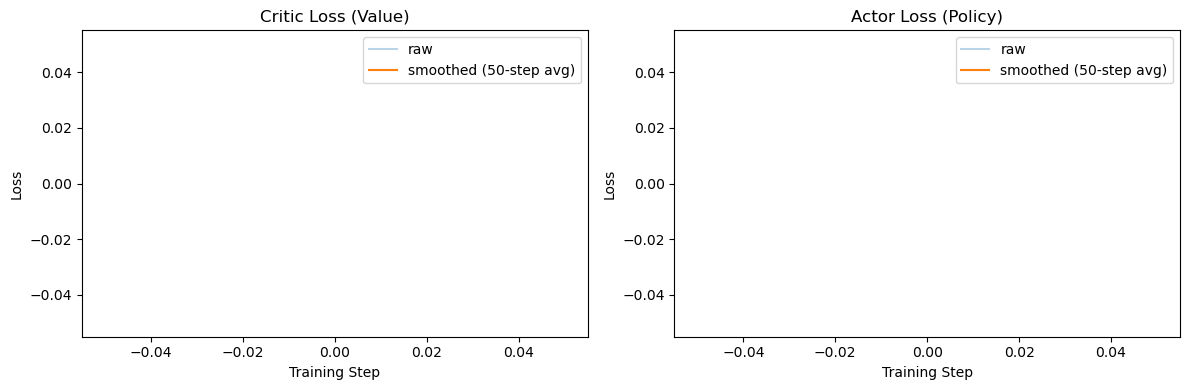

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

loss_value  = [v for _, v in logger.experiment.scalars["loss_value"]]
loss_policy = [v for _, v in logger.experiment.scalars["loss_policy"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, loss, title in zip(
    axes,
    [loss_value, loss_policy],
    ["Critic Loss (Value)", "Actor Loss (Policy)"]
):
    smoothed = pd.Series(loss).rolling(window=50).mean()
    ax.plot(loss, alpha=0.3, label="raw")
    ax.plot(smoothed, label="smoothed (50-step avg)")
    ax.set_title(title)
    ax.set_xlabel("Training Step")
    ax.set_ylabel("Loss")
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
for data in collector:
    reward = data["next", "reward"].squeeze(-1)

    with torch.no_grad():
        adv_module(data)

    # Inspect what GAE is producing
    value_target = data["value_target"]   # what GAE computed as the target
    advantage = data["advantage"]
    v_s = value_net(data)["state_value"].squeeze(-1)

    loss_td = loss_fn(data)
    loss = loss_td["loss_objective"] + loss_td["loss_critic"] + loss_td["loss_entropy"]

    optim.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(loss_fn.parameters(), max_norm=0.5)
    optim.step()

    print(
        f"Batch {collector._frames // frames_per_batch:4d} | "
        f"Reward: {reward.mean():+6.3f} | "
        f"V_target: {value_target.mean():+6.3f} (std {value_target.std():.2f}) | "
        f"V_pred: {v_s.mean():+6.3f} | "
        f"Advantage: {advantage.mean():+6.3f} (std {advantage.std():.2f}) | "
        f"Critic Loss: {loss_td['loss_critic'].item():.3f}"
    )
    
    if collector._frames // frames_per_batch >= 10:
        break

Do the loop manually!

In [11]:

from torchrl.envs import TransformedEnv, Compose, ObservationNorm, DoubleToFloat, StepCounter, RewardScaling
from torchrl.objectives import A2CLoss
from torchrl.objectives.value import TD0Estimator

base_env = GymEnv("Pendulum-v1")

base_env

RewardScaling(loc=0, scale=0.1)  # simple fixed scaling


env = TransformedEnv(
    base_env,
    Compose(
        # normalize observations
        ObservationNorm(in_keys=["observation"]),
        DoubleToFloat(),
        StepCounter(),
        RewardScaling(loc=0, scale=0.1),
    ),
)
env.transform[0].init_stats(num_iter=1000, reduce_dim=0, cat_dim=0)

from torchrl.envs import check_env_specs

check_env_specs(env)

from torchrl.modules import ProbabilisticActor, TanhNormal
from torchrl.modules import NormalParamExtractor

num_cells = 32
device = "cpu"

actor_net = nn.Sequential(
    nn.LazyLinear(num_cells, device=device),
    nn.Tanh(),
    nn.LazyLinear(num_cells, device=device),
    nn.Tanh(),
    nn.LazyLinear(num_cells, device=device),
    nn.Tanh(),
    nn.LazyLinear(2 * env.action_spec.shape[-1], device=device),
    NormalParamExtractor(),
)

policy_module = TensorDictModule(
    actor_net, in_keys=["observation"], out_keys=["loc", "scale"]
)

policy_module = ProbabilisticActor(
    module=policy_module,
    spec=env.action_spec,
    in_keys=["loc", "scale"],
    distribution_class=TanhNormal,
    distribution_kwargs={
        "low": env.action_spec_unbatched.space.low,
        "high": env.action_spec_unbatched.space.high,
    },
    return_log_prob=True,
)

#n_obs = env.observation_spec["observation"].shape[-1]

#create a model: takes observations as inputs, and outputs categorical actions
model = nn.Sequential(
    nn.LazyLinear(num_cells),
    nn.Tanh(),
    nn.LazyLinear(num_cells),
    nn.Tanh(),
    nn.LazyLinear(1),
)

#go from observations to logits using the model
value_net = TensorDictModule(
    model,
    in_keys=["observation"],
    out_keys=["state_value"],          
)

# Initialize lazy layers with a dummy forward pass
dummy_td = env.reset()
policy_module(dummy_td)   # initializes actor lazy layers
value_net(dummy_td)       # initializes critic lazy layers



from torchrl.collectors import SyncDataCollector
from torchrl.data import LazyTensorStorage, ReplayBuffer, SamplerWithoutReplacement
from torchrl.record import CSVLogger
import torch.nn.functional as F

logger = CSVLogger(exp_name="my_exp")

frames_per_batch = 200
total_frames = 1_000_000
gamma = 0.99


collector = SyncDataCollector(
    env,
    policy_module,
    frames_per_batch=frames_per_batch,
    total_frames=total_frames,
    split_trajs=False,
    device=device,
)

loss_fn = A2CLoss(
    actor_network=policy_module,
    critic_network=value_net,
    entropy_bonus=True,
    entropy_coeff=0.001,
    critic_coeff=0.5,
)

# Tell it to use TD0 advantage estimation
loss_fn.make_value_estimator(loss_fn.default_value_estimator, gamma=0.99)

optim = RMSprop(loss_fn.parameters(), lr=0.0007, eps=1e-5)

#update both the value and policy networks
#optim = Adam(value_net.parameters(),policy_module.parameters(), lr=0.0007, eps=1e-5)
#optim = RMSprop(
#    list(value_net.parameters()) + list(policy_module.parameters()),
#    lr=0.0007,
#    eps=1e-5
#)
#optim_value = Adam(value_net.parameters(), lr=0.001)
#optim_action = Adam(policy_module.parameters(), lr=0.0003)




#agent-environment interactions!
for data in collector:
    
    #collect the data
    obs    = data["observation"]
    next_obs = data["next", "observation"]
    reward = data["next", "reward"].squeeze(-1)
    done   = data["next", "done"].squeeze(-1).float()

    #reward_mean = 20 #reward.mean()
    #reward_std  = 5 #reward.std() + 1e-8
    #reward_norm = (reward - reward_mean) / reward_std

    #get current estimated value of state
    #v_s = value_net(data)["state_value"].squeeze(-1) 
    

    #calculate the td-target
    #with torch.no_grad():

        #get current estimated value of state in the next step
        #v_s_next = value_net(data["next"])["state_value"].squeeze(-1)

        #then get the target (observed reward + discounted value of the next state)
        #target = reward + gamma * (1.0 - done) * v_s_next

    # Advantage estimate
    #advantage = (target - v_s).detach()  # detach so actor loss doesn't affect critic. Use value of state without having to backpropogate through the value net from the policy net...
    #advantage = (advantage - advantage.mean()) / (advantage.std() + 1e-8)  # 

    # value loss
    #loss_value = F.mse_loss(v_s, target)
    loss_td = loss_fn(data)
    loss = loss_td["loss_objective"] + loss_td["loss_critic"] + loss_td["loss_entropy"]

    optim.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(loss_fn.parameters(), max_norm=0.5)
    optim.step()


    # policy loss
    #dist = policy_module.get_dist(data) #get the tanhnormal distribution
    #log_probs = dist.log_prob(data["action"]).squeeze() #see where the action falls in terms of tanhnormal
    #entropy = -log_probs.mean()
    #loss_action = -(log_probs * advantage).mean() - 0.001 * entropy #note: advantage here not returns anymore...
    

    #Optim update for value net
    #loss = loss_action + 0.5 * loss_value

    #optim.zero_grad()
    #loss.backward()
    #torch.nn.utils.clip_grad_norm_(
    #    list(policy_module.parameters()) + list(value_net.parameters()), 
    #    max_norm=0.5  
    #)
    #optim.step()

    #optim_value.zero_grad(set_to_none=True)
    #oss_value.backward()
    #torch.nn.utils.clip_grad_norm_(value_net.parameters(), max_norm=1.0)
    #optim_value.step()

    #Optim update for policy net
    #optim_action.zero_grad(set_to_none=True)
    #loss_action.backward()
    #torch.nn.utils.clip_grad_norm_(policy_module.parameters(), max_norm=1.0)
    #optim_action.step()

    #logger.log_scalar("loss_value", loss_value.item())
    #logger.log_scalar("loss_policy", loss_action.item())

    print(
    f"Batch {collector._frames // frames_per_batch:4d} | "
    f"Reward: {reward.mean().item():+7.3f} | "
    f"Value Loss: {loss_td["loss_objective"]:7.3f} | "
    f"Policy Loss: {loss_td["loss_critic"]:+7.3f} | "
    #f"Advantage: {advantage.mean().item():+6.3f} | "
    #f"Adv std: {advantage.std().item():6.3f} | "
    #f"Value Est: {v_s.mean().item():+6.3f}"
    )
    

2026-03-10 11:45:58,612 [torchrl][INFO]    check_env_specs succeeded! [END]


/home/titan2/data/conda-envs/torchrl_latest/lib/python3.12/site-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(


Batch    1 | Reward:  -0.832 | Value Loss: -17.215 | Policy Loss:  +6.164 | 
Batch    2 | Reward:  -0.814 | Value Loss: -16.375 | Policy Loss:  +5.994 | 
Batch    3 | Reward:  -0.507 | Value Loss: -10.043 | Policy Loss:  +3.627 | 
Batch    4 | Reward:  -0.607 | Value Loss: -11.883 | Policy Loss:  +4.607 | 
Batch    5 | Reward:  -0.746 | Value Loss: -15.601 | Policy Loss:  +5.600 | 
Batch    6 | Reward:  -0.527 | Value Loss: -10.842 | Policy Loss:  +3.852 | 
Batch    7 | Reward:  -0.459 | Value Loss:  -9.287 | Policy Loss:  +3.373 | 
Batch    8 | Reward:  -0.717 | Value Loss: -13.410 | Policy Loss:  +5.266 | 
Batch    9 | Reward:  -0.695 | Value Loss: -13.824 | Policy Loss:  +4.979 | 
Batch   10 | Reward:  -0.566 | Value Loss: -11.842 | Policy Loss:  +4.202 | 
Batch   11 | Reward:  -0.656 | Value Loss: -13.698 | Policy Loss:  +4.810 | 
Batch   12 | Reward:  -0.648 | Value Loss: -12.891 | Policy Loss:  +4.586 | 
Batch   13 | Reward:  -0.864 | Value Loss: -17.064 | Policy Loss:  +6.315 | 

KeyboardInterrupt: 

It would be good here to have a standard print statement for these training loops and go over how to diagnose issues with the training. If we do this early it might help a lot down the road when dealing with more complext algorithms;

* value loss way too high (should be meaningfull to the rewards per state)
* Value estimate always high (way too confident)
* Policy loss near zero (no learning signal, )

In [ ]:
logger.experiment

In [ ]:
loss_value  = logger.experiment.metrics["loss_value"]

import pandas as pd
import matplotlib.pyplot as plt

smoothed = pd.Series(loss_value).rolling(window=50).mean()

plt.plot(loss_value, alpha=0.3, label="raw")
plt.plot(smoothed, label="smoothed (50-step avg)")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Value Loss over Time")
plt.legend()
plt.show()

AttributeError: 'CSVExperiment' object has no attribute 'metrics'

In [ ]:
print(logger.experiment.__dict__)

{'scalars': defaultdict(<class 'list'>, {'loss_value': [(0, 47.6292724609375), (1, 48.51974868774414), (2, 52.50786590576172), (3, 54.404354095458984), (4, 41.54323196411133), (5, 44.90016555786133), (6, 53.613338470458984), (7, 47.797000885009766), (8, 42.8596076965332), (9, 49.18098068237305), (10, 47.97506332397461), (11, 49.45173645019531), (12, 51.27006912231445), (13, 47.48440933227539), (14, 55.24311065673828), (15, 45.47034454345703), (16, 52.95829772949219), (17, 60.059940338134766), (18, 50.71654510498047), (19, 48.492061614990234), (20, 48.3405647277832), (21, 52.24375534057617), (22, 52.25686264038086), (23, 45.905784606933594), (24, 55.7701416015625), (25, 48.71284866333008), (26, 51.66775894165039), (27, 52.54164123535156), (28, 42.92711639404297), (29, 51.036163330078125), (30, 47.56341552734375), (31, 54.541236877441406), (32, 53.85478591918945), (33, 44.52656173706055), (34, 55.23616409301758), (35, 59.34189987182617), (36, 45.527305603027344), (37, 55.2620735168457), 

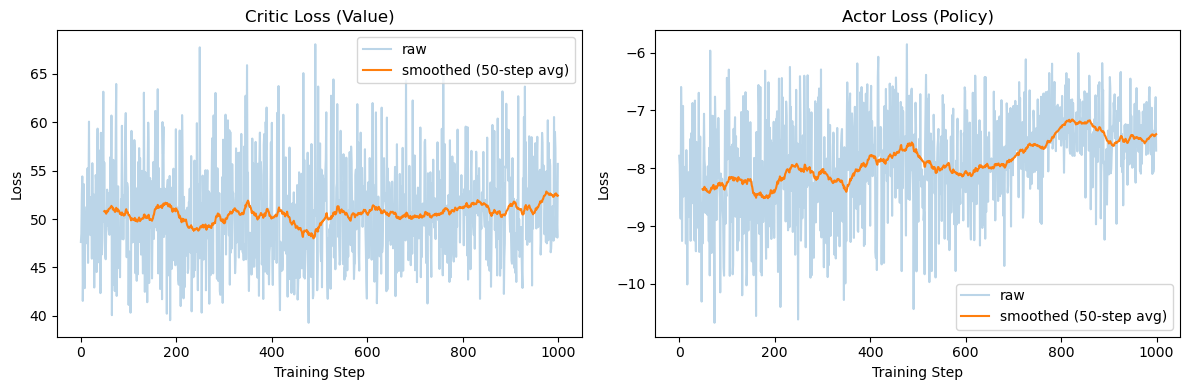

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

loss_value  = [v for _, v in logger.experiment.scalars["loss_value"]]
loss_policy = [v for _, v in logger.experiment.scalars["loss_policy"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, loss, title in zip(
    axes,
    [loss_value, loss_policy],
    ["Critic Loss (Value)", "Actor Loss (Policy)"]
):
    smoothed = pd.Series(loss).rolling(window=50).mean()
    ax.plot(loss, alpha=0.3, label="raw")
    ax.plot(smoothed, label="smoothed (50-step avg)")
    ax.set_title(title)
    ax.set_xlabel("Training Step")
    ax.set_ylabel("Loss")
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
loss_policy = logger.experiment.metrics["loss_policy"]

import pandas as pd
import matplotlib.pyplot as plt

smoothed = pd.Series(loss_policy).rolling(window=50).mean()

plt.plot(loss_policy, alpha=0.3, label="raw")
plt.plot(smoothed, label="smoothed (50-step avg)")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Policy Loss over Time")
plt.legend()
plt.show()